In [53]:
import pandas as pd
from pathlib import Path
import numpy as np

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

[PosixPath('data/futures/6E.parquet'),
 PosixPath('data/futures/6J.parquet'),
 PosixPath('data/futures/CL.parquet'),
 PosixPath('data/futures/ES.parquet'),
 PosixPath('data/futures/GC.parquet'),
 PosixPath('data/futures/NG.parquet'),
 PosixPath('data/futures/NQ.parquet'),
 PosixPath('data/futures/SI.parquet'),
 PosixPath('data/futures/YM.parquet'),
 PosixPath('data/futures/ZB.parquet'),
 PosixPath('data/futures/ZN.parquet')]

In [54]:
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)

In [55]:
earliest_per_ticker = df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
earliest_per_ticker

,ticker,timestamp
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [56]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)
df

,timestamp,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [57]:
def get_agnostic_tokens(df, n_bins=10):
    # 1. Calculate True Range and ATR
    high_low = df["high"] - df["low"]
    high_pc = (df["high"] - df["close"].shift(1)).abs()
    low_pc = (df["low"] - df["close"].shift(1)).abs()

    
    tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    
    # conviction and explosion (ATR may be NaN for the first rows)
    conviction = (df["close"] - df["open"]) / atr
    explosion = (df["high"] - df["low"]) / atr

    df["non_zero_volume"] = df["volume"] + 1e-12

    # relative volume
    rel_volume = df["non_zero_volume"] / (df["non_zero_volume"].rolling(50).mean())

    norm_return = np.log(df["close"].shift(-1) / df["close"]) / atr
    ret_codes = pd.qcut(norm_return, q=n_bins, labels=False, duplicates="drop")

    # quantile bins — keep index alignment (don't dropna here)
    c_codes = pd.qcut(conviction, q=n_bins, labels=False, duplicates='drop')
    e_codes = pd.qcut(explosion, q=n_bins, labels=False, duplicates='drop')
    rv_codes = pd.qcut(rel_volume, q=n_bins, labels=False, duplicates='drop')

    # any position missing in one should be considered missing in all -> create combined mask
    mask = (c_codes == -1) | (e_codes == -1) | (rv_codes == -1)
    c_codes[mask] = None
    e_codes[mask] = None
    rv_codes[mask] = None

    c_codes = c_codes.dropna()
    e_codes = e_codes.dropna()
    rv_codes = rv_codes.dropna()

    # debug counts (should match)
    # print((c_codes == -1).sum(), (e_codes == -1).sum(), (rv_codes == -1).sum())

    # convert to strings and join into a single token
    c_s = c_codes.astype(int).astype(str)
    e_s = e_codes.astype(int).astype(str)
    rv_s = rv_codes.astype(int).astype(str)

    tokens = c_s + "_" + e_s + "_" + rv_s
    return tokens, ret_codes

number_of_classes = 10
# compute tokens per ticker and store back into the main df
df['token'] = None
for _, g in df.groupby('ticker', sort=False):
    df.loc[g.index, 'token'], df.loc[g.index, "ret"] = get_agnostic_tokens(g, n_bins=number_of_classes)

df.dropna()

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,timestamp,close,high,low,open,volume,ticker,token,ret
49,2002-06-13,0.941800,0.947200,0.939500,0.943700,0,6E,3_4_5,8.0
50,2002-06-14,0.945400,0.952600,0.941700,0.943000,0,6E,6_7_5,2.0
51,2002-06-17,0.942900,0.946600,0.941200,0.944800,0,6E,3_1_5,8.0
52,2002-06-18,0.947400,0.948300,0.939800,0.940600,0,6E,9_5_5,8.0
53,2002-06-19,0.952700,0.954200,0.948000,0.948000,0,6E,8_2_5,9.0
...,...,...,...,...,...,...,...,...,...
65678,2025-12-11,112.609375,112.812500,112.578125,112.578125,937,ZN,5_1_0,1.0
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN,1_4_0,6.0
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN,2_0_0,8.0
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN,7_8_0,4.0


In [58]:
# align all tickers to a common timestamp index and rebuild a compact (T_common, N, 1) integer array
# pivot tokens so each column is a ticker and index are timestamps
token_pivot = df.pivot(index="timestamp", columns="ticker", values="token").sort_index()
ret_pivot = df.pivot(index="timestamp", columns="ticker", values="ret").sort_index()


# keep only timestamps present for every ticker
common_mask = token_pivot.notna().all(axis=1) & ret_pivot.notna().all(axis=1)
T_common = int(common_mask.sum())
print("T_common:", T_common)

# restrict pivot to the common timestamps (ensures every column has the same index)
token_pivot = token_pivot.loc[common_mask]
ret_pivot = ret_pivot.loc[common_mask]

# tickers in consistent order
tickers = token_pivot.columns.tolist()
N = len(tickers)
print("N (tickers):", N, "tickers:", tickers)

token_pivot

T_common: 5885
N (tickers): 11 tickers: ['6E', '6J', 'CL', 'ES', 'GC', 'NG', 'NQ', 'SI', 'YM', 'ZB', 'ZN']


ticker,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
timestamp,,,,,,,,,,,
2002-06-14,6_7_5,9_7_5,8_6_4,3_8_0,1_4_6,9_7_4,5_8_0,3_0_0,3_8_0,9_8_0,8_4_1
2002-06-17,3_1_5,2_0_5,4_0_1,9_8_0,3_2_9,3_3_2,9_6_0,3_0_4,9_5_0,0_5_0,1_4_0
2002-06-18,9_5_5,4_1_5,1_6_1,7_2_0,8_3_4,4_8_3,7_3_0,3_0_0,8_0_0,4_2_0,1_3_0
2002-06-19,8_2_5,8_3_5,4_6_1,0_6_0,3_1_7,5_6_4,0_8_0,3_0_2,2_5_0,7_0_8,6_0_9
2002-06-20,8_8_5,7_6_5,5_3_8,1_4_0,7_5_6,0_9_7,1_4_0,6_3_0,1_3_8,0_8_4,0_8_5
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-11,9_8_9,7_7_9,0_8_6,6_8_6,9_8_7,0_9_9,3_8_5,7_5_8,9_9_7,2_6_0,5_1_0
2025-12-12,5_0_6,2_2_3,2_2_2,0_9_9,7_9_8,2_2_6,0_9_7,0_6_8,1_6_7,0_7_0,1_4_0
2025-12-15,7_3_1,8_6_1,1_6_2,3_5_6,4_6_8,1_3_3,2_6_1,7_4_8,3_3_1,4_0_0,2_0_0


In [59]:
ret_pivot

ticker,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
timestamp,,,,,,,,,,,
2002-06-14,2.0,2.0,8.0,9.0,0.0,6.0,9.0,0.0,9.0,0.0,1.0
2002-06-17,8.0,8.0,0.0,8.0,9.0,2.0,9.0,8.0,8.0,5.0,5.0
2002-06-18,8.0,8.0,3.0,0.0,7.0,5.0,0.0,3.0,0.0,9.0,9.0
2002-06-19,9.0,7.0,9.0,0.0,9.0,1.0,0.0,9.0,0.0,0.0,0.0
2002-06-20,9.0,9.0,7.0,1.0,8.0,6.0,4.0,1.0,0.0,9.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-11,4.0,2.0,3.0,2.0,5.0,2.0,2.0,2.0,3.0,0.0,1.0
2025-12-12,7.0,9.0,2.0,4.0,4.0,2.0,3.0,5.0,4.0,6.0,6.0
2025-12-15,6.0,9.0,0.0,3.0,4.0,2.0,4.0,4.0,2.0,9.0,8.0


In [60]:
bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(columns={"symbol": "ticker"})
bigger_df["token"], bigger_df["ret"] = get_agnostic_tokens(bigger_df)
bigger_df = bigger_df.dropna()
bigger_df

,ticker,timestamp,open,high,low,close,volume,trade_count,vwap,non_zero_volume,token,ret
49,IBM,2016-01-04 15:01:00+00:00,135.200,135.230,135.170,135.2097,6165.0,70.0,135.197375,6165.0,5_1_2,0.0
50,IBM,2016-01-04 15:02:00+00:00,135.210,135.220,134.950,134.9788,75225.0,446.0,135.058478,75225.0,0_9_9,9.0
51,IBM,2016-01-04 15:03:00+00:00,134.990,135.200,134.980,135.2000,21139.0,231.0,135.051264,21139.0,9_8_8,0.0
52,IBM,2016-01-04 15:04:00+00:00,135.200,135.240,135.000,135.0050,11781.0,115.0,135.151855,11781.0,0_9_4,5.0
53,IBM,2016-01-04 15:05:00+00:00,134.950,135.050,134.950,135.0100,8339.0,86.0,135.014671,8339.0,7_3_2,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
950901,IBM,2024-12-31 20:57:00+00:00,219.590,219.880,219.550,219.8800,25000.0,470.0,219.737460,25000.0,9_8_9,2.0
950902,IBM,2024-12-31 20:58:00+00:00,219.845,219.880,219.660,219.7250,32448.0,645.0,219.770273,32448.0,2_6_9,8.0
950903,IBM,2024-12-31 20:59:00+00:00,219.730,220.000,219.710,219.9900,77490.0,1186.0,219.851196,77490.0,9_7_9,2.0
950904,IBM,2024-12-31 21:00:00+00:00,219.830,219.830,219.830,219.8300,596294.0,46.0,219.830000,596294.0,4_0_9,0.0


In [61]:
df = df.dropna()
vocab = df["token"].unique().tolist()
vocab_len = len(vocab)

T = len(token_pivot)
N = len(df["ticker"].unique())

T, N

(5885, 11)

In [62]:
# build integer mapping once (vocab is defined in the notebook)
token_to_id = {tok: i for i, tok in enumerate(vocab)}

# allocate array (T,N,1) with integer dtype
all_sequences = np.zeros((T, N, 1), dtype=np.int32)
all_targets = np.zeros((T, N))

for idx, sym in enumerate(tickers):
    seq_ids = token_pivot[sym].map(token_to_id).astype(np.int32).values
    assert seq_ids.shape[0] == T
    all_sequences[:, idx, 0] = seq_ids
    all_targets[:, idx] = ret_pivot[sym].astype(np.int32)

all_sequences.shape, all_sequences.dtype

((5885, 11, 1), dtype('int32'))

In [63]:
all_targets

array([[2., 2., 8., ..., 9., 0., 1.],
       [8., 8., 0., ..., 8., 5., 5.],
       [8., 8., 3., ..., 0., 9., 9.],
       ...,
       [6., 9., 0., ..., 2., 9., 8.],
       [3., 0., 8., ..., 3., 3., 4.],
       [8., 8., 7., ..., 6., 0., 2.]], shape=(5885, 11))

In [64]:
# build dataset

# build dataloader

# instantiate model

# train model

# inspect

In [65]:
from model.my_dataset import MyDataset
from torch.utils.data import DataLoader
from model.model_definition import SimpleTransformer
from model.training import train_loop
import torch

In [66]:
class_freqs = np.unique(all_targets, return_counts=True)[1]

In [ ]:
train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], 64)
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], 64)

train_dataloader = DataLoader(train_dataset)
val_dataloader = DataLoader(val_dataset)



# pass frequencies to the model (as a list)
model = SimpleTransformer(vocab, 64, number_of_classes, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)

res = train_loop(model, train_dataloader, val_dataloader, 100, 4e-6, 1e-5, torch.device("cpu"), "checkpoint", 10)

Training on device: cpu
Trainable parameters: 58698
Training samples: 4645, Validation samples: 1114
--------------------------------------------------------------------------------
New best model saved at epoch 1
Epoch: 0 | Train loss: 2.4081383510606025 | Val loss: 2.3515259192276687


In [ ]:
import matplotlib.pyplot as plt

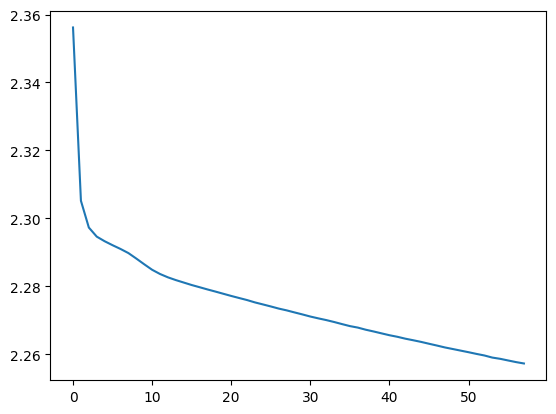

In [ ]:
plt.plot(res["history"]["train_loss"])

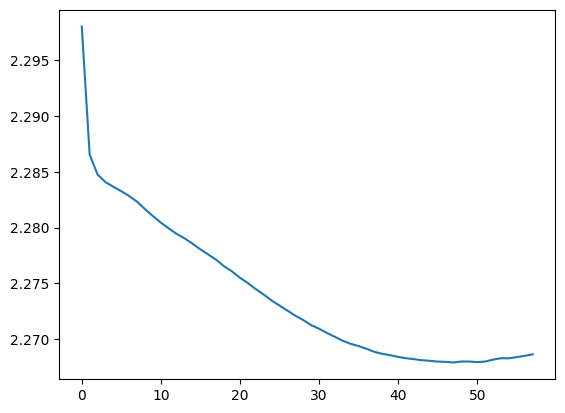

In [ ]:
plt.plot(res["history"]["val_loss"])

In [ ]:
model.eval()
with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
        preds, _ = model(x_batch)
        # print(preds)
        break
preds

tensor([[[[0.0781, 0.0813, 0.1104,  ..., 0.1135, 0.0928, 0.0586],
          [0.0685, 0.0858, 0.1043,  ..., 0.1225, 0.0905, 0.0597],
          [0.1022, 0.1067, 0.0993,  ..., 0.1176, 0.1142, 0.1063],
          ...,
          [0.0816, 0.0905, 0.1041,  ..., 0.1199, 0.0977, 0.0741],
          [0.0682, 0.0814, 0.1109,  ..., 0.1168, 0.0916, 0.0518],
          [0.0741, 0.0908, 0.1109,  ..., 0.1227, 0.0946, 0.0567]],

         [[0.0734, 0.0878, 0.1114,  ..., 0.1120, 0.0929, 0.0631],
          [0.0747, 0.0900, 0.1088,  ..., 0.1147, 0.0963, 0.0684],
          [0.1036, 0.0971, 0.1078,  ..., 0.1092, 0.1008, 0.0976],
          ...,
          [0.0768, 0.0917, 0.1057,  ..., 0.1206, 0.0967, 0.0745],
          [0.0597, 0.0790, 0.1161,  ..., 0.1090, 0.0795, 0.0456],
          [0.0776, 0.0815, 0.1061,  ..., 0.1183, 0.0991, 0.0648]],

         [[0.0646, 0.0848, 0.1090,  ..., 0.1147, 0.0918, 0.0531],
          [0.0745, 0.0926, 0.1019,  ..., 0.1168, 0.1039, 0.0643],
          [0.1039, 0.1097, 0.0943,  ..., 0

In [ ]:
preds = preds.squeeze(0)

In [ ]:
preds = preds.view(preds.shape[0]*preds.shape[1], preds.shape[2])

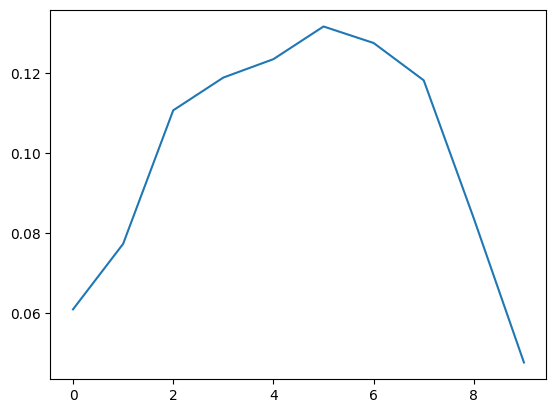

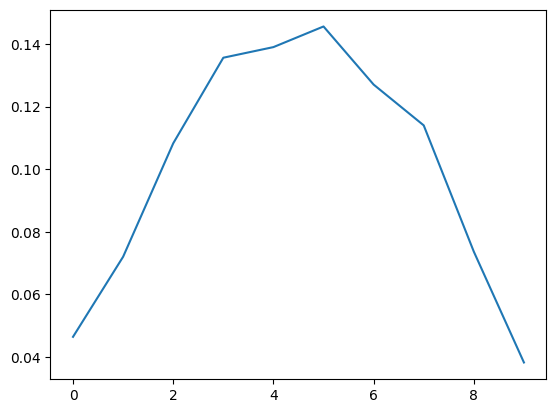

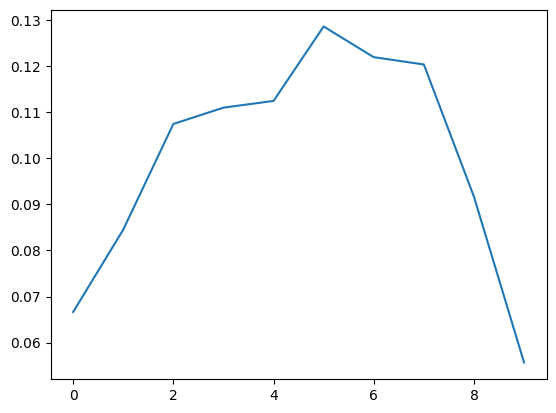

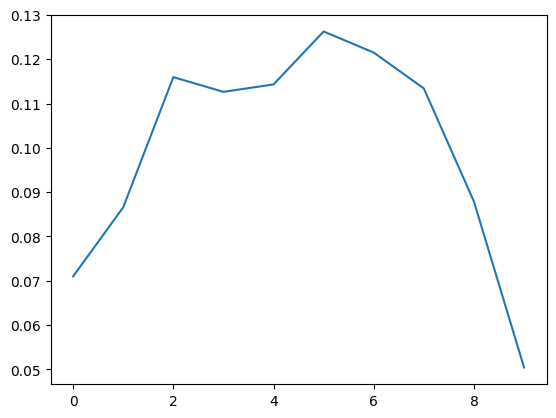

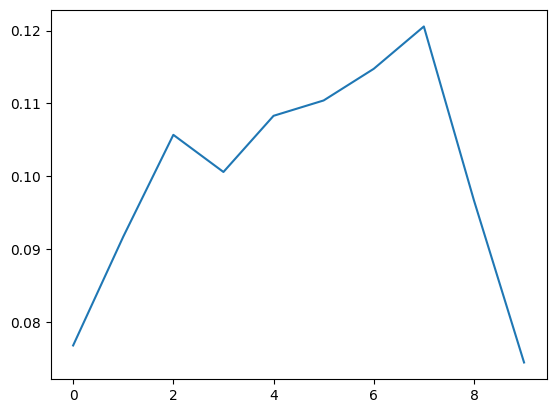

In [ ]:
for i in range(15, 20):
    plt.plot(preds[i])
    plt.show()